# Breast Cancer Classification with a simple Neural Network (NN)

In [44]:
# A neural network is a machine learning model inspired by the human brain, utilizing interconnected nodes (neurons) in layers 
# to process data, recognize patterns, and make predictions. 
# They are fundamental to modern AI, enabling advancements in computer vision, natural language processing (NLP), and speech recognition
# by learning complex, non-linear relationships directly from dat

#see nn.png

#In NN, first layer is input layer, last layer is o/p layer.

# Neural networks operate through a structured flow of information across 3 main types of layers:
# Input Layer: Receives the raw data, such as pixels from an image or text from a document.
# Hidden Layers: Where the actual "learning" happens. These layers perform mathematial transformations to identify increasingly 
# complex pattens.
# Output Layer: Provides the final result, such as a prediction (e.g. "this is a cat") or a classification.

#there can be min of 3 to max infi layer in a NN model 
#e.g. 5 layer -> 1 i/p, 3 hidden, 1 o/p

# Every connection between neurons has 2 primary parameters that the network adjusts during training:
# 1. Weights:
# These determine the "strength" or importanc of a particular input signal.
# 2. Biases:
# These allow the model to shift its output, giving it more flexibilty to learn complex data.

# Activation Functions: 
# These functions (like ReLU or Sigmoid) decide whether a neuron should "fire" or pass its signal to the next layer, allowing the 
# network to handle non-linear relationship.

# Different tasks require different network architectures:
# Convolutional Neural Networks (CNNs): Specialized for visual tasks like image and video recognition.
# Recurrent Neural Networks (RNNs): Designed for sequential data, such as language translation or speech recognitin, bcz they have
# a "memory" of previous inputs.
# Feedforward Neural Networks: The simplest form where data travels in one direction, from input to outpu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

In [3]:
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [3]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [17]:
# breast_cancer_dataset is kind of dict with data, target as key

In [4]:
# load the data to a dataframe
df = pd.DataFrame(breast_cancer_dataset.data, columns = breast_cancer_dataset.feature_names)

In [5]:
# add the 'target' col to the df
df['label'] = breast_cancer_dataset.target

In [6]:
df.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
303,10.490,18.61,66.86,334.3,0.10680,0.06678,0.02297,0.01780,0.1482,0.06600,...,24.54,70.76,375.4,0.1413,0.10440,0.08423,0.06528,0.2213,0.07842,1
418,12.700,12.17,80.88,495.0,0.08785,0.05794,0.02360,0.02402,0.1583,0.06275,...,16.92,88.12,566.9,0.1314,0.16070,0.09385,0.08224,0.2775,0.09464,1
373,20.640,17.35,134.80,1335.0,0.09446,0.10760,0.15270,0.08941,0.1571,0.05478,...,23.17,166.80,1946.0,0.1562,0.30550,0.41590,0.21120,0.2689,0.07055,0
175,8.671,14.45,54.42,227.2,0.09138,0.04276,0.00000,0.00000,0.1722,0.06724,...,17.04,58.36,259.2,0.1162,0.07057,0.00000,0.00000,0.2592,0.07848,1
392,15.490,19.97,102.40,744.7,0.11600,0.15620,0.18910,0.09113,0.1929,0.06744,...,29.41,142.10,1359.0,0.1681,0.39130,0.55530,0.21210,0.3187,0.10190,0


In [7]:
df.shape

(569, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
# chk for missing values in each col
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
label                      0
dtype: int64

In [12]:
#get statistical measures about the data -> numerical cols
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [8]:
# check the distribution of Target Varibale
df['label'].value_counts()

label
1    357
0    212
Name: count, dtype: int64

<Axes: ylabel='count'>

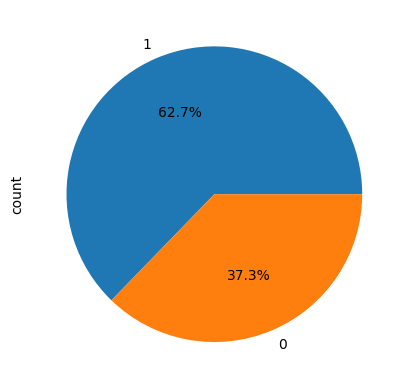

In [33]:
df['label'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [ ]:
# 1 --> Benign
# 0 --> Malignant

In [9]:
#analyse mean of all cols for both the values of label:
df.groupby('label').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


In [ ]:
#Insight: malignant stage ka col vals are generaly > than Benign stage

In [7]:
# Split the features and target:

X = df.drop(columns=['label'])
Y = df['label']

X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [9]:
print(X.shape, X_train.shape, X_test.shape)

(569, 30) (455, 30) (114, 30)


In [10]:
#standardize the data -> mean centric data -> mean = 0 and std dev is 1
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_std = sc.fit_transform(X_train)

X_test_std = sc.transform(X_test)

# Building the Neural Network

In [11]:
# import tensorflow and Keras

import tensorflow as tf  #or pytorch v use kr skt 
tf.random.set_seed(3)
from tensorflow import keras

In [12]:
# setting up the layers of Neural Network:
# generl format: keras.layers.Dense(no_of_neurons, activation=activation_func),  

model = keras.Sequential([
                          keras.layers.Flatten(input_shape=(30,)),       #i/p layer
                          keras.layers.Dense(20, activation='relu'),     #hidden layer
                          keras.layers.Dense(2, activation='sigmoid')    #o/p layer
])

#there can be min of 3 to max infi layer in a NN model 
#e.g. 5 layer -> 1 i/p, 3 hidden, 1 o/p

# Here we are defining a simple Sequential neural network using Keras that takes 30 input features and processes them through 2 layers
# to produce a fina classificatn:
#1. The Input Layer (Flatten)
# Purpose: It takes your input data with a shape of (30,) and ensures it is a flat 1D array.
# Rol: xplicitly defines that the network expects 30 individual values as the entry point.

# 2. The Hidden Layer (Dense)Configuration: 
# 20 neurons with the ReLU (Rectified Linear Unit) activation function.
# Role: This is where the model learns complex patterns.
# ReLU is the standard choice here because it helps the network learn faster by outputting the input directy if it is
# positiv, and zero otherwise.

# 3. The Output Layer (Dense)Configuration: -> 2 hi de skte idhar as we hav 2 classes in o/p, any other val will raise error
# 2 neurons with the Sigmoid activation function.
# Role: This layer produces the final prediction.
#-> Using 2 neurons suggests you are likely performing a classification task with two posible categories.
# The Sigmoid function squashes the output values between (0) and (1), which is typically used to represent probabilities.

C:\Users\KIIT\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# compil the Neural Networ

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# This line of code is the "configuration" step for a deep learning model in Keras or TensorFlow. 
# It tells the model how to learn from data before you start the actual trainig proces


Here is a breakdown of each component:
# optimizer='adam': This is the algorithm that adjusts the model's weights to minimize errors.
# Adam is a popular, efficient choe that combins the bes propertis of other algo to handle noisy data and larg datasets effectively.

# loss='sparse_categorical_crossentropy': This is the "scoring" function that measures how wrong the model's predictions are.
# This specific version is used for multi-class classification (e.g. identifying a digit 0–9) where your labels are integers (like 1, 2, 3) 
# rather than "one-hot" encoded vectors (like [0, 1, 0]).

# metrics=['accuracy']: This defines what performance data you want to see during training. While the "loss" is for the computer to 
# optimize, "accuracy" is for you—it shows the perc

In [14]:
# train the Meural Network

history = model.fit(X_train_std, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.4377 - loss: 0.7885 - val_accuracy: 0.6304 - val_loss: 0.6491
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7995 - loss: 0.5650 - val_accuracy: 0.8478 - val_loss: 0.4723
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8875 - loss: 0.4318 - val_accuracy: 0.9130 - val_loss: 0.3696
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9242 - loss: 0.3497 - val_accuracy: 0.9348 - val_loss: 0.3038
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9413 - loss: 0.2927 - val_accuracy: 0.9348 - val_loss: 0.2577
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9487 - loss: 0.2510 - val_accuracy: 0.9783 - val_loss: 0.2238
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9511 - loss: 0.2195 - val_accuracy: 0.9783 - val_loss: 0.1979
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9560 - loss: 0.1949 - val_accuracy: 0.9783 - v

In [16]:
history.history['accuracy']

[0.4376528263092041,
 0.7995110154151917,
 0.8875305652618408,
 0.9242053627967834,
 0.9413203001022339,
 0.9486552476882935,
 0.95110023021698,
 0.955990195274353,
 0.955990195274353,
 0.9584352374076843]

In [ ]:
#on training data:
#accuracy: 0.9584 
# validation_acuracy: 0.9783 

# Visualize accuracy and loss


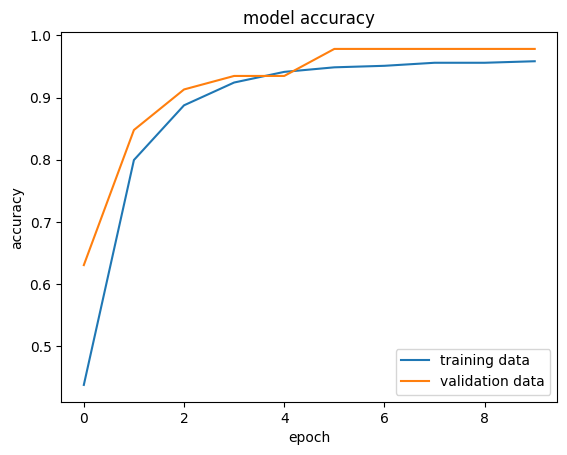

In [18]:
#accuracy and validatn acuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'lower right')

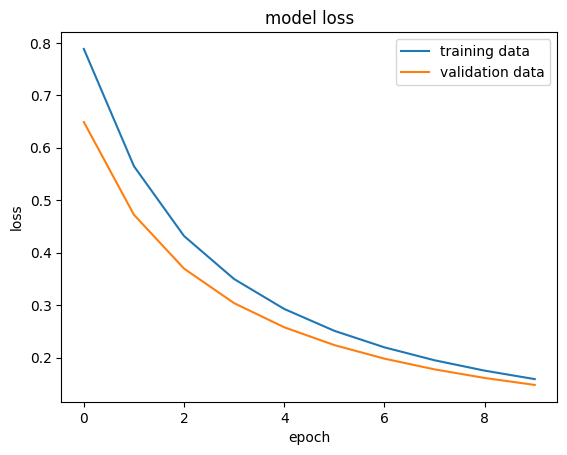

In [22]:
#loss and validatn loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'upper right')

# Accuracy of the model on test data

In [31]:
#ML me evaluate method ni hota -> pehle predict krte fir accuracy_score,r2_score calc krte
loss, accuracy = model.evaluate(X_test_std, Y_test)
print(accuracy)

# In Deep Learnin (specifically Keras and TensorFlo), the model.evaluate() method is a built-in function that summarizes how well your
# trained neural network performs on a datast.
# It’s the Deep Learnin versin of accuracy_score with upgrad -> return loss + acuracy 
#  .evaluate() compares the model's predicted ans to the true labels you provided and retun a score.

# Command: model.evaluate(X_test, y_test)
# Returns [loss, accuracy]
# Mus run model.compile() first

# ML: fit -> y_pred = model.predict(X) -> accuracy_score(y_true, y_pred)
# DL: fit -> test_score = model.evaluate(X, y)
# i.e 
# In Scikit-Learn, you have to run predict() first and then pas those res into accuracy_score funct. 
# In DL, model.evaluate does the predicting and the scoring in one single line.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9474 - loss: 0.1537
0.9473684430122375


In [25]:
#insight: 0.947 = beter than logistic regressio

In [24]:
print(X_test_std.shape)
print(X_test_std[0])

(114, 30)
[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419  0.63336386  0.26335737  0.53209124  2.62763999
  0.62351167  0.11405261  1.01246781  0.41126289  0.63848593  2.88971815
 -0.41675911  0.74270853 -0.32983699 -1.67435595 -0.36854552 -0.38767294
  0.32655007 -0.74858917 -0.54689089 -0.18278004 -1.23064515 -0.6268286 ]


In [26]:
Y_pred = model.predict(X_test_std)

# model.predict() gives the predictn probability of each class for that data point

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [27]:
print(Y_pred.shape)
print(Y_pred[0])

(114, 2)
[0.6474718 0.5967411]


In [28]:
#  argmax function

my_list = [0.25, 0.56]

index_of_max_value = np.argmax(my_list)
print(my_list)
print(index_of_max_value)

[0.25, 0.56]
1


In [30]:
# convert the predictn probability to class labels

Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)

# Build the predictiv system

In [35]:
input_data = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115,0.1495,0.05888,0.4062,1.21,2.635,28.47,0.005857,0.009758,0.01168,0.007445,0.02406,0.001769,12.98,25.72,82.98,516.5,0.1085,0.08615,0.05523,0.03715,0.2433,0.06563)

# change the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

input_data_std = sc.transform(input_data_reshaped)  # standardiz the input data

prediction = model.predict(input_data_std)
print(prediction)

prediction_label = [np.argmax(prediction)]
print(prediction_label)

if(prediction_label[0] == 0):
  print('The tumor is Malignant')
else:
  print('The tumor is Benign')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

C:\Users\KIIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
[[0.10894269 0.7584511 ]]
[np.int64(1)]
The tumor is Benign
